In [18]:
import pandas as pd
from pathlib import Path

csv_path = Path("spambase_csv.csv")
df = pd.read_csv(csv_path)
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [19]:
print("Dataset shape:", df.shape)

target_counts = df["class"].value_counts().sort_index()
print("\nTarget distribution:")
print(target_counts)

print("\nTarget distribution (%):")
print(target_counts / len(df) * 100)

Dataset shape: (4601, 58)

Target distribution:
class
0    2788
1    1813
Name: count, dtype: int64

Target distribution (%):
class
0    60.595523
1    39.404477
Name: count, dtype: float64


In [20]:
print("Null values per column:")
print(df.isnull().sum())

print("\nTotal null values:", df.isnull().sum().sum())

print("\nDescriptive statistics:")
print(df.describe())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataFrame info:")
df.info()

Null values per column:
word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet

In [21]:
# Inspect whether duplicate rows are exact duplicates across all columns
dup_mask = df.duplicated(keep=False)
dup_rows = df.loc[dup_mask]

print("Rows that are duplicated (including all copies):", dup_rows.shape[0])
print("Unique duplicated row patterns:", dup_rows.drop_duplicates().shape[0])
print("Repeated rows beyond the first occurrence:", df.duplicated().sum())

if dup_rows.empty:
    print("No exact duplicate rows found.")
else:
    print("First duplicated rows:")
    print(dup_rows.head(10))

Rows that are duplicated (including all copies): 571
Unique duplicated row patterns: 180
Repeated rows beyond the first occurrence: 391
First duplicated rows:
     word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
24             0.00                0.0           0.00           0.0   
26             0.00                0.0           0.00           0.0   
101            0.00                0.0           0.64           0.0   
102            0.00                0.0           0.00           0.0   
103            0.00                0.0           0.64           0.0   
104            0.00                0.0           0.00           0.0   
105            0.00                0.0           0.64           0.0   
106            0.00                0.0           0.00           0.0   
108            0.00                0.0           0.00           0.0   
116            0.05                0.3           0.40           0.0   

     word_freq_our  word_freq_over  word_freq_remove  word_

In [22]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4210, 58)


In [23]:
X = df.drop(columns=["class"])
y = df["class"]

Shape: (4210, 58)

Class distribution:
class
0    2531
1    1679
Name: count, dtype: int64

Class distribution (%):
class
0    60.12
1    39.88
Name: proportion, dtype: float64


/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_26243/221681054.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=ax, palette="viridis")


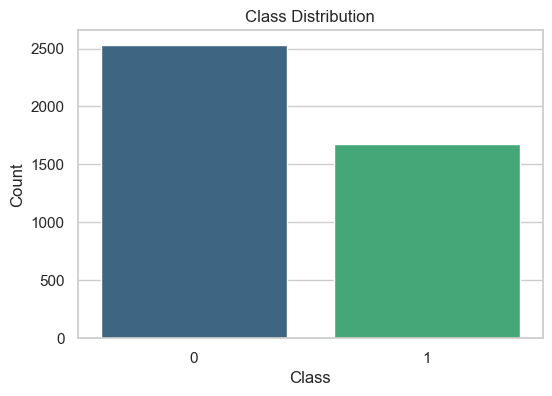


Top correlated features with class:
word_freq_your        0.3944
word_freq_remove      0.3345
char_freq_%24         0.3266
word_freq_000         0.3257
word_freq_free        0.2793
word_freq_receive     0.2725
word_freq_hp         -0.2700
word_freq_business    0.2608
word_freq_you         0.2562
word_freq_hpl        -0.2424
dtype: float64


/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_26243/221681054.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_features.values, y=top_corr_features.index, ax=ax, palette="magma")


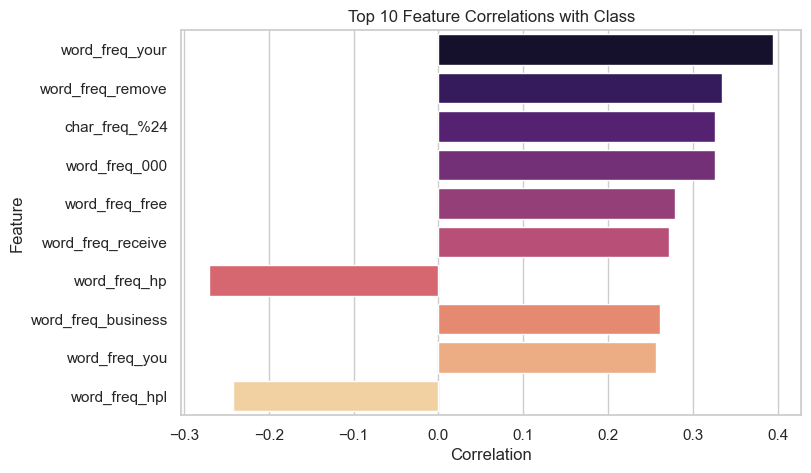

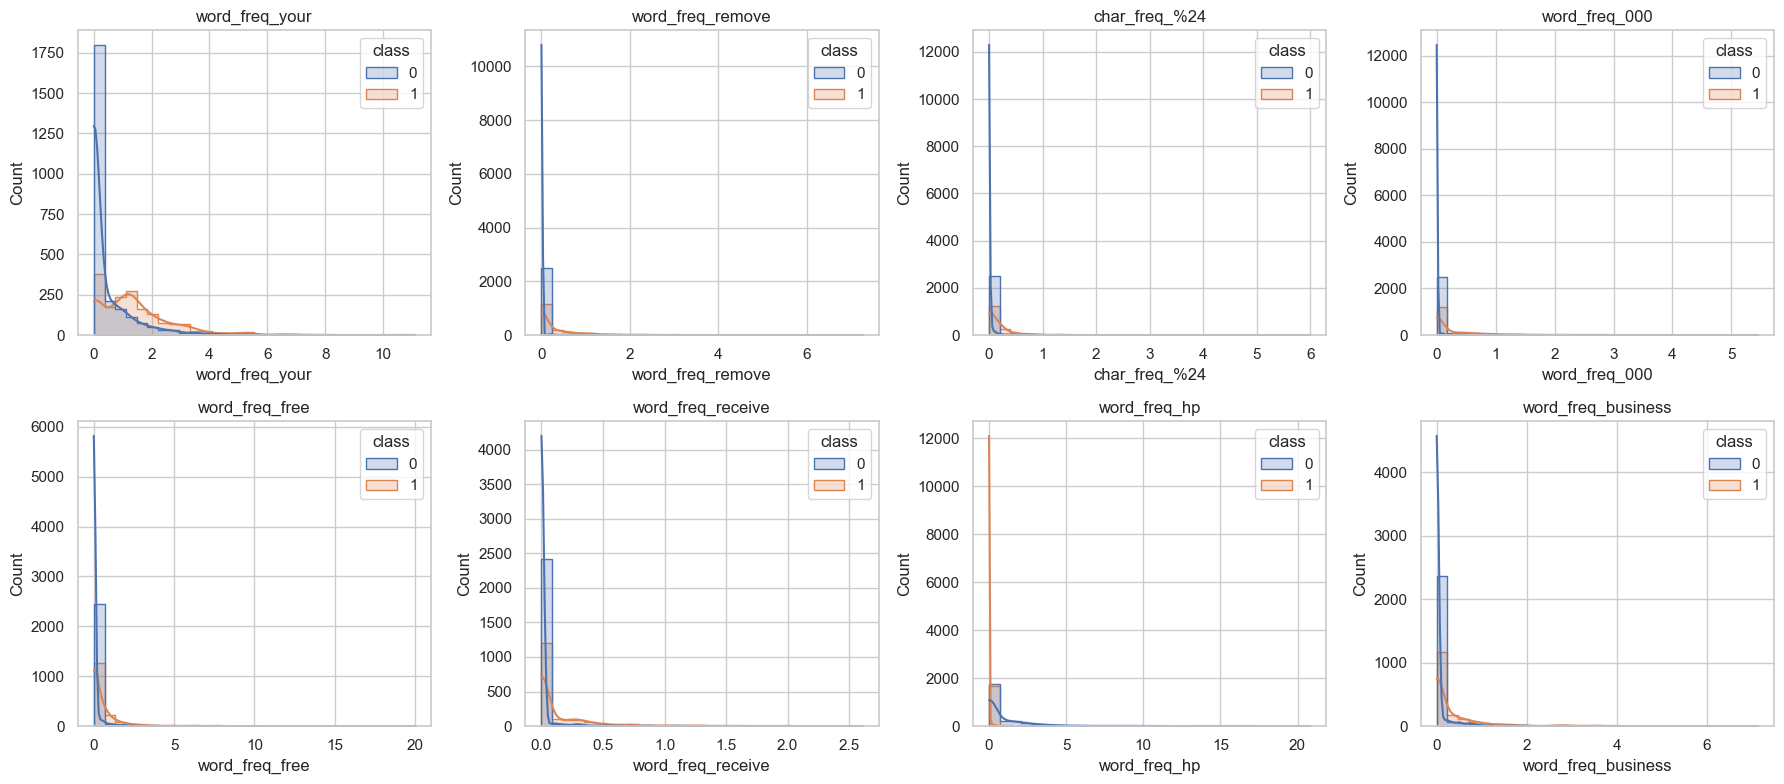

/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_26243/221681054.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y=col, ax=axes[i], palette="Set2")
/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_26243/221681054.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y=col, ax=axes[i], palette="Set2")
/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_26243/221681054.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y=col, ax=axes[i], palette="Set2"

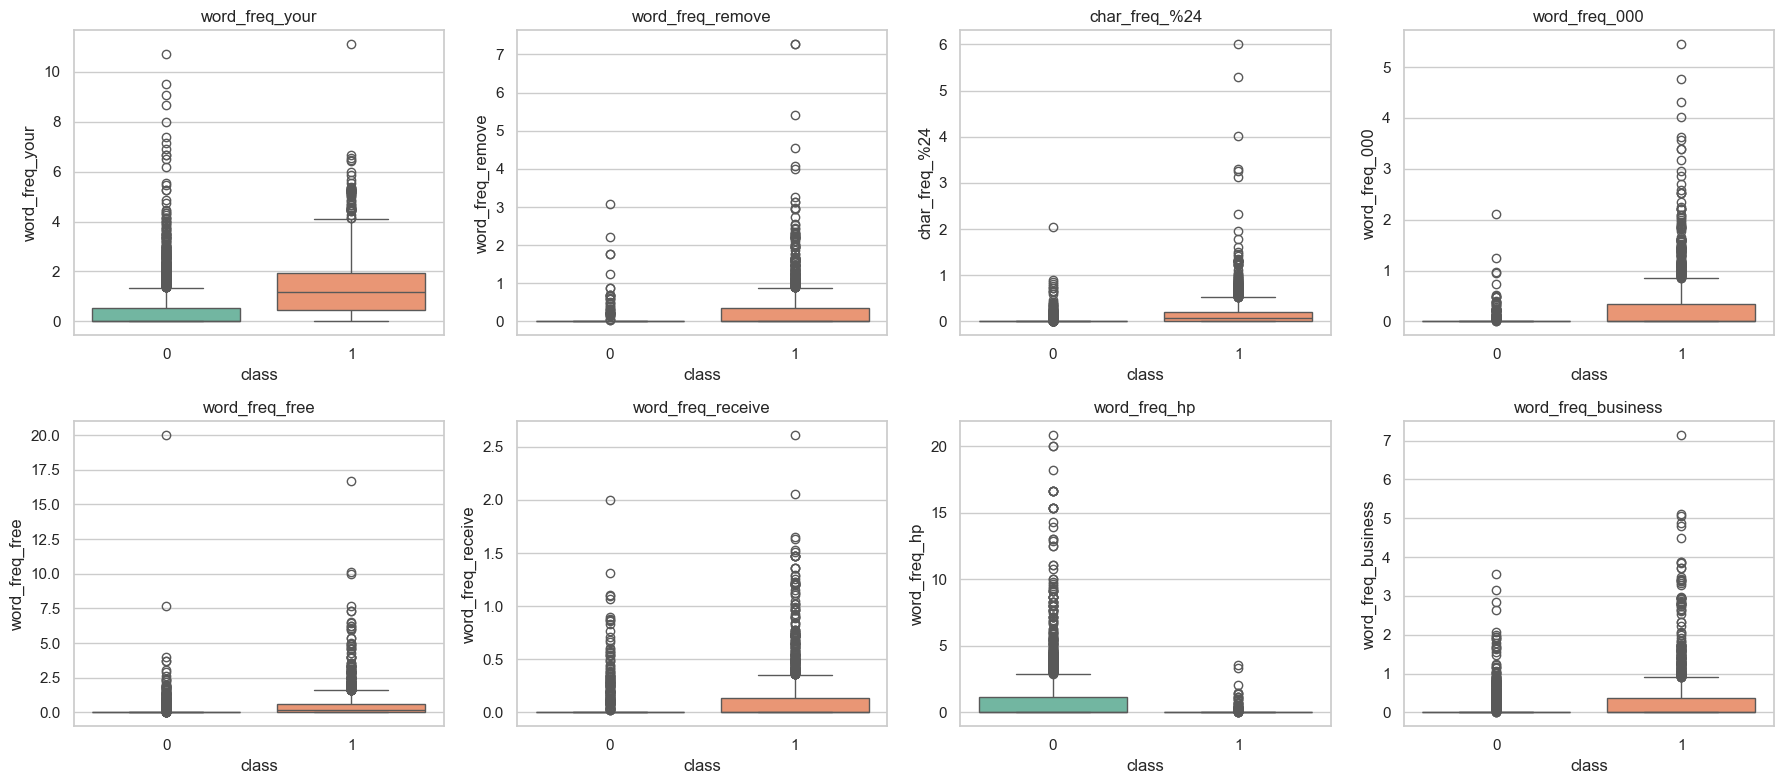

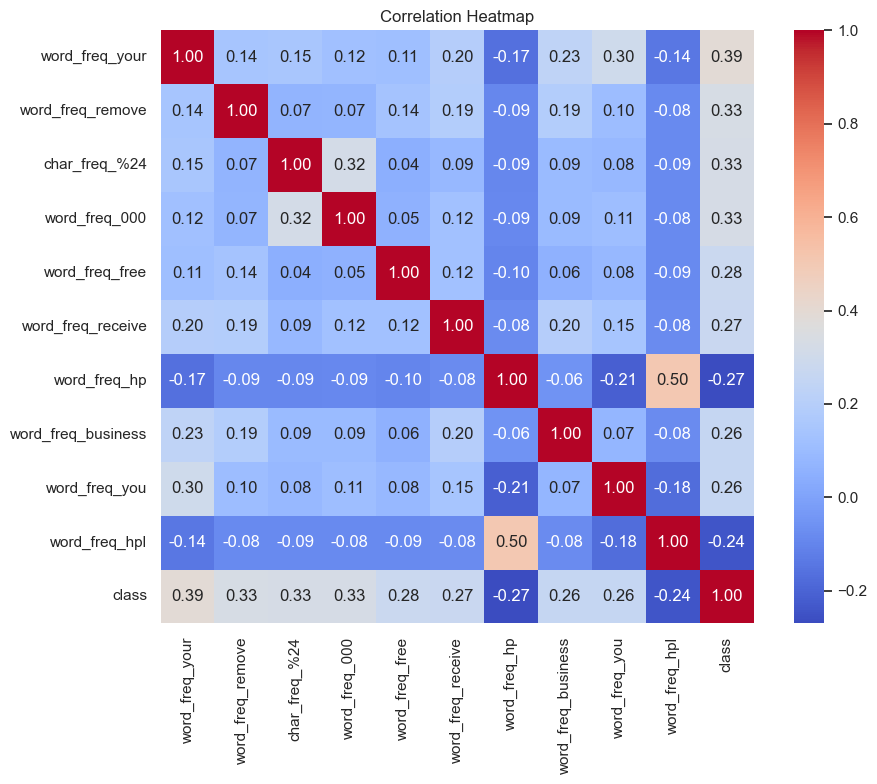

In [24]:
import seaborn as sns

import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Basic overview
print("Shape:", df.shape)
print("\nClass distribution:")
print(y.value_counts().sort_index())
print("\nClass distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

# Target plot
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y, ax=ax, palette="viridis")
ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()

# Top features by absolute correlation with the target
feature_corr = X.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
top_corr_features = feature_corr.head(10)

print("\nTop correlated features with class:")
print(top_corr_features.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_corr_features.values, y=top_corr_features.index, ax=ax, palette="magma")
ax.set_title("Top 10 Feature Correlations with Class")
ax.set_xlabel("Correlation")
ax.set_ylabel("Feature")
plt.show()

# Distributions of the most correlated features
top_features = top_corr_features.index[:8]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(top_features):
    sns.histplot(data=df, x=col, hue="class", bins=30, kde=True, ax=axes[i], element="step")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Boxplots for the same features by class
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(top_features):
    sns.boxplot(data=df, x="class", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Correlation heatmap for the most informative features
heatmap_features = list(top_corr_features.index) + ["class"]
corr_matrix = df[heatmap_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3368, 57)
X_test shape: (842, 57)
y_train shape: (3368,)
y_test shape: (842,)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (3368, 57)
X_test_scaled shape: (842, 57)


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ])
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_score)
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
print(results_df.round(4))

                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
0        Random Forest    0.9466     0.9477  0.9167  0.9319   0.9893
1  Logistic Regression    0.9347     0.9297  0.9048  0.9170   0.9768
2                  SVM    0.9323     0.9319  0.8958  0.9135   0.9772


In [30]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_score_best = best_rf.predict_proba(X_test)[:, 1]

print("\nTest metrics with best Random Forest:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_pred_best), 4))
print("Recall:", round(recall_score(y_test, y_pred_best), 4))
print("F1:", round(f1_score(y_test, y_pred_best), 4))
print("ROC_AUC:", round(roc_auc_score(y_test, y_score_best), 4))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 score: 0.9336

Test metrics with best Random Forest:
Accuracy: 0.943
Precision: 0.9417
Recall: 0.9137
F1: 0.9275
ROC_AUC: 0.9893


Actual test-set metrics:
Accuracy: 0.943
Precision: 0.9417
Recall: 0.9137
F1: 0.9275
ROC_AUC: 0.9893

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       506
           1       0.94      0.91      0.93       336

    accuracy                           0.94       842
   macro avg       0.94      0.94      0.94       842
weighted avg       0.94      0.94      0.94       842



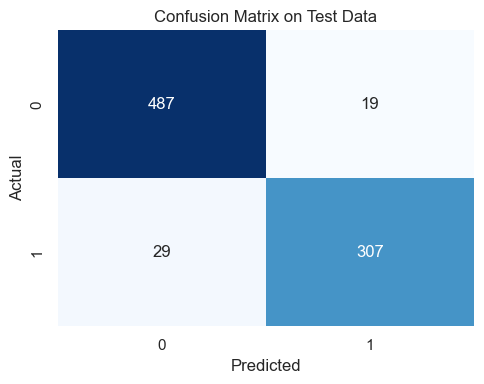

,Actual,Predicted,Probability
1043,1,1,0.760000
2717,0,0,0.036667
765,1,1,0.993333
1177,1,0,0.236667
1798,0,1,0.560000
2862,0,0,0.003333
475,1,0,0.410833
959,1,1,1.000000
3161,0,0,0.000000
306,1,1,0.940000


In [31]:
from sklearn.metrics import confusion_matrix, classification_report

# Check performance on the actual test labels

y_pred_actual = (y_score_best >= 0.5).astype(int)

print("Actual test-set metrics:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_actual), 4))
print("Precision:", round(precision_score(y_test, y_pred_actual), 4))
print("Recall:", round(recall_score(y_test, y_pred_actual), 4))
print("F1:", round(f1_score(y_test, y_pred_actual), 4))
print("ROC_AUC:", round(roc_auc_score(y_test, y_score_best), 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred_actual))

cm = confusion_matrix(y_test, y_pred_actual)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix on Test Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_actual,
    "Probability": y_score_best
}, index=y_test.index)

comparison.head(10)